In [2]:
# R2424224
# HDSC 2.2
# CALTON SHANJI
# TIME SERIES REGIME CHANGE MODEL
# MARKOV SWITCHING REGRESSION

# : IMPORT LIBRARIES
# ===========================================================

# Definition of the Regime Switching Model

## Mathematical Definition

## The Markov Regime Switching model is defined as:

# **y_t = μ_(s_t) + ε_t**

## Where:
## - y_t : observed financial return at time t  
## - μ_(s_t) : mean return in regime s_t  
## - s_t : unobserved regime (state of the market)  
## - ε_t : error term (random shock)  
## - ε_t ~ N(0, σ²_(s_t))

## The regime variable s_t follows a Markov process, meaning that the probability of moving from one regime to another depends only on the current state, not past history.


# **Description (Plain Explanation)**

## This model assumes that financial markets switch between different hidden states over time, such as low-volatility and high-volatility periods. Each state has its own statistical behavior in terms of mean returns and variance.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

import warnings
warnings.filterwarnings('ignore')

In [4]:
!pip install yfinance

In [12]:
# ============================================================
# : IMPORT FINANCIAL DATA
# ========================================================

In [13]:
import yfinance as yf

# Download S&P 500 data
df = yf.download('^GSPC',
                 start='2017-01-01',
                 end='2025-01-01')

# Display first rows
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open      Volume
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC       ^GSPC
Date                                                                      
2017-01-03  2257.830078  2263.879883  2245.129883  2251.570068  3773010000
2017-01-04  2270.750000  2272.820068  2261.600098  2261.600098  3768890000
2017-01-05  2269.000000  2271.500000  2260.449951  2268.179932  3785080000
2017-01-06  2276.979980  2282.100098  2264.060059  2271.139893  3342080000
2017-01-09  2268.899902  2275.489990  2268.899902  2273.590088  3219730000


In [35]:
print(df.columns)

Index(['Price'], dtype='object')


In [33]:

# ============================================================
# QUESTION 3: KEEP ADJUSTED CLOSE PRICE

In [36]:
print(df.head())

# Rename column
df.columns = ['Price']

print(df.head())


                  Price
Date                   
2017-01-03  2257.830078
2017-01-04  2270.750000
2017-01-05  2269.000000
2017-01-06  2276.979980
2017-01-09  2268.899902
                  Price
Date                   
2017-01-03  2257.830078
2017-01-04  2270.750000
2017-01-05  2269.000000
2017-01-06  2276.979980
2017-01-09  2268.899902


In [37]:
# ============================================================
# : COMPUTE DAILY RETURNS
# ============================================================

df['Returns'] = np.log(df['Price'] / df['Price'].shift(1))

# Remove missing values
df.dropna(inplace=True)

print(df.head())

                  Price   Returns
Date                             
2017-01-04  2270.750000  0.005706
2017-01-05  2269.000000 -0.000771
2017-01-06  2276.979980  0.003511
2017-01-09  2268.899902 -0.003555
2017-01-10  2268.899902  0.000000


In [38]:
# ============================================================
# QUESTION 5: PLOT STOCK PRICES
# ============================================================



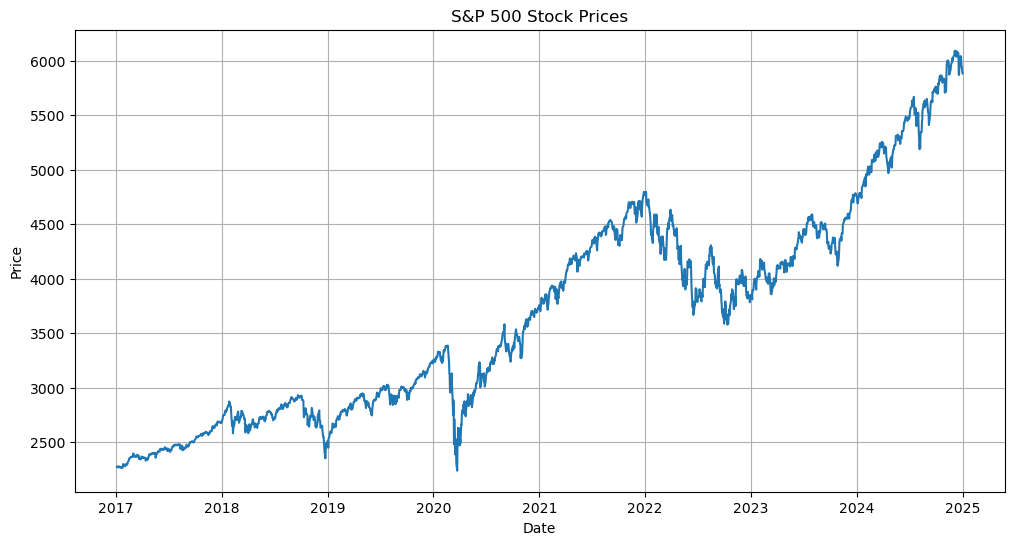

In [39]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Price'])

plt.title('S&P 500 Stock Prices')
plt.xlabel('Date')
plt.ylabel('Price')

plt.grid(True)

plt.show()

In [40]:
# ============================================================
# : PLOT RETURNS
# ============================================================



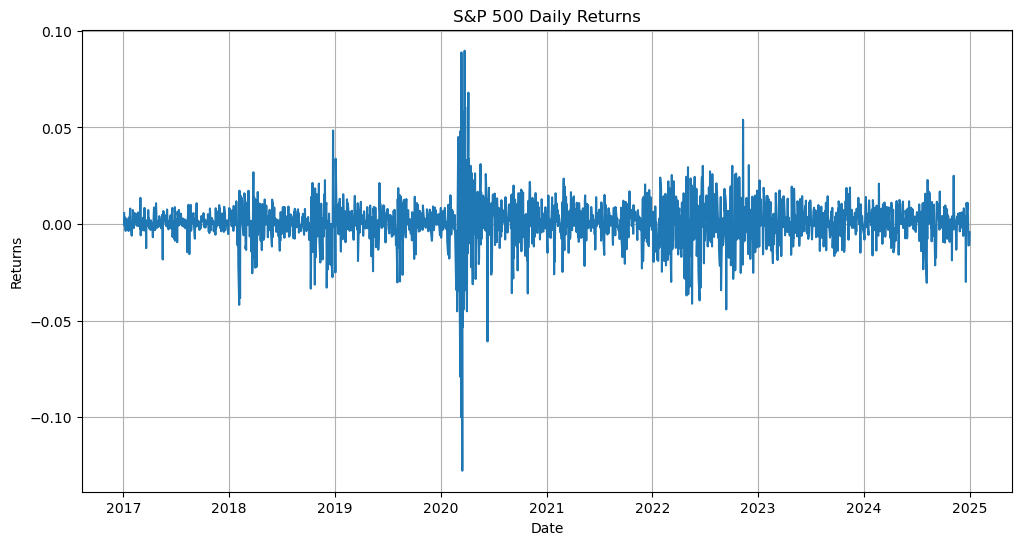

In [41]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df['Returns'])

plt.title('S&P 500 Daily Returns')
plt.xlabel('Date')
plt.ylabel('Returns')

plt.grid(True)

plt.show()

In [42]:
# ============================================================
# : SUMMARY STATISTICS
# ============================================================



In [43]:
print(df.describe())

             Price      Returns
count  2011.000000  2011.000000
mean   3677.032039     0.000476
std     977.206386     0.011762
min    2237.399902    -0.127652
25%    2798.395020    -0.003768
50%    3678.429932     0.000767
75%    4382.334961     0.006053
max    6090.270020     0.089683


In [44]:
# ============================================================
# : FIT MARKOV SWITCHING MODEL
# ============================================================



In [45]:
model = MarkovRegression(
    df['Returns'],
    k_regimes=2,
    trend='c',
    switching_variance=True
)

results = model.fit()


In [46]:
# ============================================================
# : MODEL OUTPUT
# ============================================================




In [47]:
print(results.summary())

                        Markov Switching Model Results                        
Dep. Variable:                Returns   No. Observations:                 2011
Model:               MarkovRegression   Log Likelihood                6570.124
Date:                Thu, 07 May 2026   AIC                         -13128.247
Time:                        18:32:33   BIC                         -13094.609
Sample:                             0   HQIC                        -13115.900
                               - 2011                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.000      6.736      0.000       0.001       0.002
sigma2      3.593e-05   2.62e-06     13.712      0.0

In [48]:
# ============================================================
# : PLOT REGIME PROBABILITIES
# ============================================================



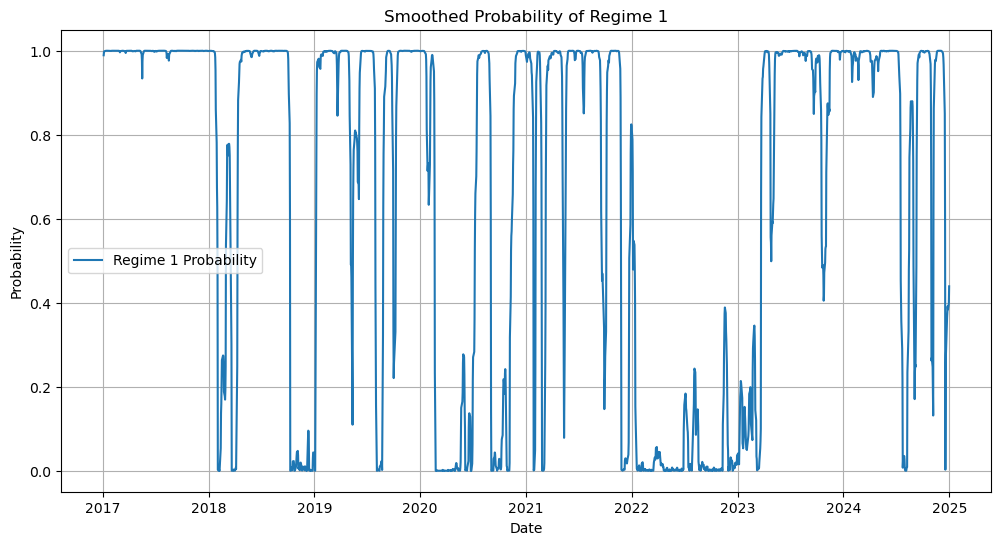

In [49]:
plt.figure(figsize=(12,6))

plt.plot(results.smoothed_marginal_probabilities[0],
         label='Regime 1 Probability')

plt.title('Smoothed Probability of Regime 1')
plt.xlabel('Date')
plt.ylabel('Probability')

plt.legend()

plt.grid(True)

plt.show()

In [50]:
# ============================================================
# : PLOT REGIME 2 PROBABILITIES
# ============================================================



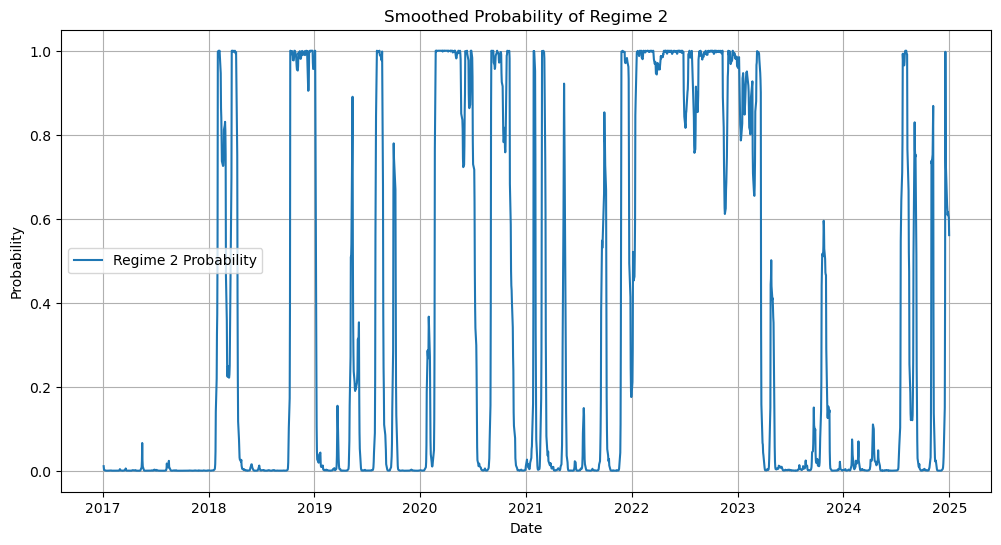

In [51]:
plt.figure(figsize=(12,6))

plt.plot(results.smoothed_marginal_probabilities[1],
         label='Regime 2 Probability')

plt.title('Smoothed Probability of Regime 2')
plt.xlabel('Date')
plt.ylabel('Probability')

plt.legend()

plt.grid(True)

plt.show()

In [52]:
# : RESIDUAL DIAGNOSTICS
# ============================================================




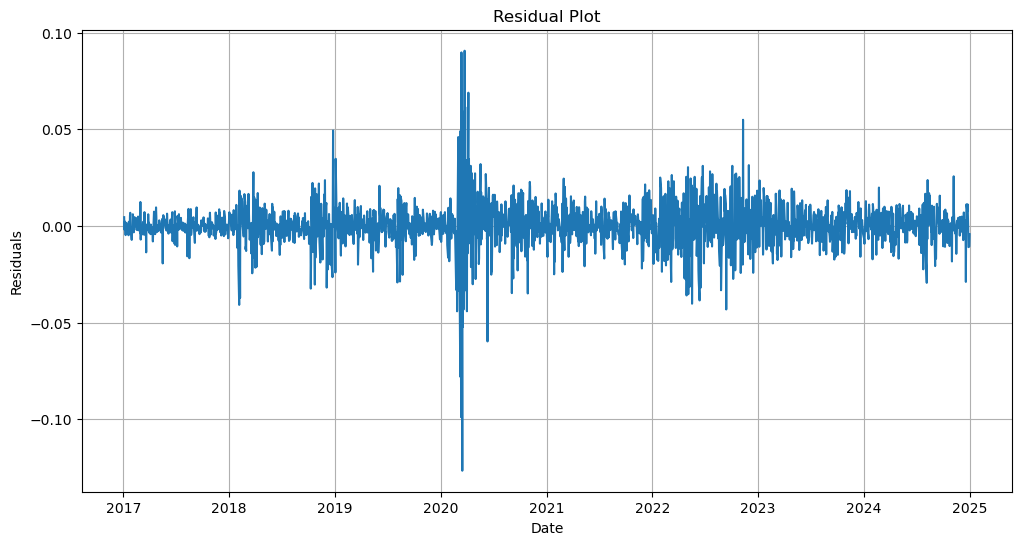

In [53]:
residuals = results.resid

plt.figure(figsize=(12,6))

plt.plot(residuals)

plt.title('Residual Plot')
plt.xlabel('Date')
plt.ylabel('Residuals')

plt.grid(True)

plt.show()

In [54]:
# ============================================================

# ============================================================
# : INTERPRETATION
# ============================================================



In [55]:
print("""
INTERPRETATION

Regime 1 generally represents periods of lower volatility
and stable market behavior.

Regime 2 represents periods of higher volatility and
financial stress.

The model identifies changes between calm and turbulent
market conditions over time.
""")


INTERPRETATION

Regime 1 generally represents periods of lower volatility
and stable market behavior.

Regime 2 represents periods of higher volatility and
financial stress.

The model identifies changes between calm and turbulent
market conditions over time.

